# Introduction to PyTorch Geometric

See official tutorials:
- https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html
- https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_gnn.html \

In [1]:
import numpy as np
import torch
from torch_geometric.data import Data
import torch_geometric.utils as U
import networkx as nx
import matplotlib.pyplot as plt

PyG Graph Construction
----------------------

PyG represents a graph as a `Data` object.
You can construct a graph by specifying source and destination nodes
in `edge_index` with shape `[2, num_edges]`. Nodes in the graph have
consecutive IDs starting from 0.




In [2]:
def get_star_graph(num_nodes=7):

    ### Star graph with the center node (0) receiving edges from all other nodes

    edge_index = torch.tensor([
            [1, 2, 3, 4, 5, 6],  # destination node index
            [0, 0, 0, 0, 0, 0]   # source node index
        ])

    return Data(edge_index=edge_index, num_nodes=7)

In [3]:
star_graph = get_star_graph()
print(star_graph)

Data(edge_index=[2, 6], num_nodes=7)


### **NOTE**: By default, edges are _directional_
We can append a swapped copy of `src` and `dst` arrays or simply use `torch_geometric.utils.to_undirected` to make connections go both ways...

In [4]:
edge_index_bothways = torch.cat([star_graph.edge_index, 
                                 star_graph.edge_index[[1, 0]]], 
                                 dim=1)

star_graph_bothways = Data(edge_index=edge_index_bothways, num_nodes=6)

### We can visualize the graphs using `networkx`

In [5]:
def plot_graph(g, ax, pos=None, node_feats=None, edge_feats=None, with_labels=True):
    nx_g = U.to_networkx(g, to_undirected=False)

    node_color = 'lightblue'
    edge_color = 'black'

    if pos is None:
        pos = nx.spring_layout(nx_g)
    else:
        pos = {i: pos[i].tolist() for i in range(pos.shape[0])}

    ### Set node color based on node features (if provided)
    if node_feats is not None:
        assert node_feats.shape == (g.num_nodes, 1) \
            or node_feats.shape == (g.num_nodes,), "Only scalar node feats supported"
        node_color = node_feats.squeeze().numpy()
    if edge_feats is not None:
        assert edge_feats.shape == (g.num_edges, 1) \
            or edge_feats.shape == (g.num_edges,), "Only scalar edge feats supported"
        edge_color = edge_feats.squeeze().numpy()

    nx.draw(nx_g, 
            ax=ax, 
            pos=pos,
            with_labels=with_labels, 
            node_color=node_color, 
            edge_color=edge_color, 
            node_size=500)

    ax.set_aspect('equal')

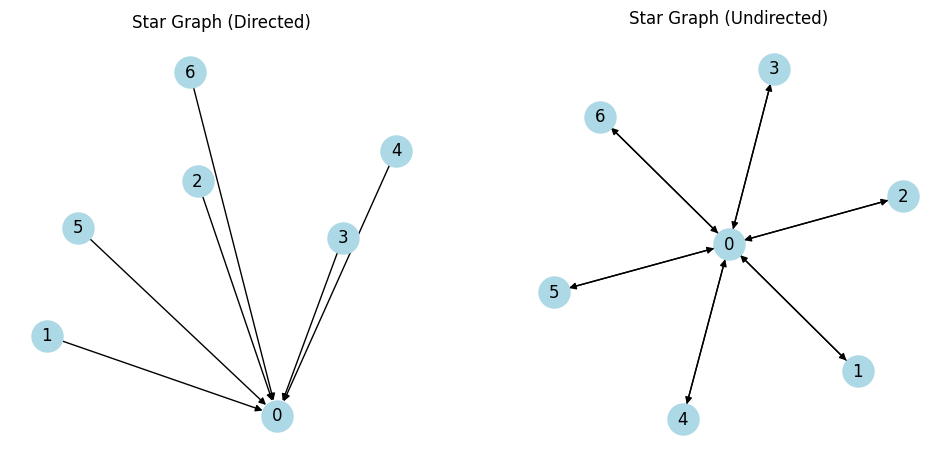

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_graph(star_graph, ax[0])
ax[0].set_title("Star Graph (Directed)")
plot_graph(star_graph_bothways, ax[1])
ax[1].set_title("Star Graph (Undirected)")
plt.show()

### Two more examples

In [7]:
### Graph where each node connects to the next one
def get_loop_graph(num_nodes=8):
    edges_src = torch.arange(num_nodes)
    edges_dst = torch.roll(edges_src, shifts=-1)
    loop_graph = Data(edge_index=torch.stack([edges_dst, edges_src]), num_nodes=num_nodes)
    return loop_graph

In [8]:
### Densely connected mesh graph with 5 nodes
def get_dense_graph(num_nodes=5):
    edges_src = torch.arange(num_nodes).repeat_interleave(num_nodes - 1)
    edges_dst = torch.cat([torch.cat([torch.arange(i), torch.arange(i+1, num_nodes)]) for i in range(num_nodes)])
    dense_graph = Data(edge_index=torch.stack([edges_src, edges_dst]), num_nodes=num_nodes)
    return dense_graph

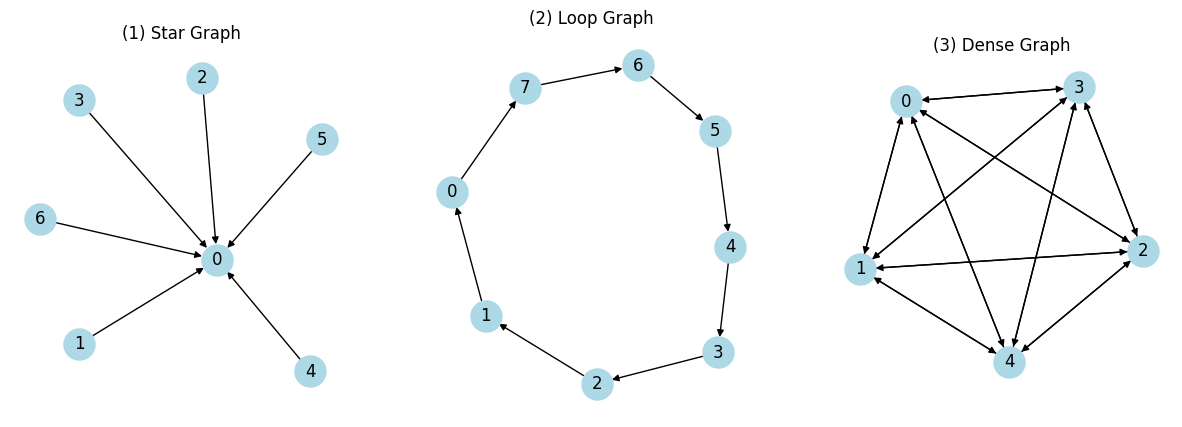

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

graph_collection = {
    "Star Graph": star_graph,
    "Loop Graph": get_loop_graph(),
    "Dense Graph": get_dense_graph()
}

for i, (name, g_) in enumerate(graph_collection.items()):
    axes[i].set_title(f"({i+1}) {name}")
    plot_graph(g_, axes[i])

Assigning Node and Edge Features to Graph
-----------------------------------------

We can simply assign tensors to the `torch_geometric.data.Data` object to serve as features:

- **Graph-level shape**: `(feat_dim, )`
- **Node-level shape**:  `(num_nodes, feat_dim)`
- **Edge-level shape**:  `(num_edges, feat_dim)`


In [10]:
def decorate_graph(g):

    num_nodes = g.num_nodes
    num_edges = g.edge_index.shape[1]

    # A scalar feature for the entire graph
    g.graph_feature = torch.tensor([1.0])

    # A 2-dimensional node feature (position)
    g.x = torch.stack([torch.arange(num_nodes) * (0.5 - (torch.arange(num_nodes) % 2 == 0).float()) * 2,
                       torch.arange(num_nodes) ** 2 / 4], dim=1)

    # A scalar node feature
    g.node_feature = torch.ones(num_nodes, 1, dtype=torch.float)

    # A scalar edge feature
    g.edge_feature = torch.randn(num_edges, 1)

In [11]:
decorate_graph(star_graph)
print(star_graph)

Data(edge_index=[2, 6], num_nodes=7, graph_feature=[1], x=[7, 2], node_feature=[7, 1], edge_feature=[6, 1])


In [12]:
star_graph.x

tensor([[-0.0000,  0.0000],
        [ 1.0000,  0.2500],
        [-2.0000,  1.0000],
        [ 3.0000,  2.2500],
        [-4.0000,  4.0000],
        [ 5.0000,  6.2500],
        [-6.0000,  9.0000]])

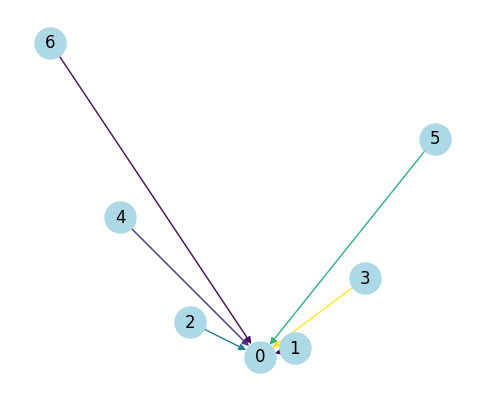

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plot_graph(star_graph, ax, pos=star_graph.x, edge_feats=star_graph.edge_feature)

# Message passing

<img src="https://github.com/WeizmannMLcourse/MLCourse_2025/blob/main/Tutorial8_GNN/messages.jpeg?raw=1"  width="500" height="665">

## Simple message-passing example: counting incoming edges

In [14]:
### 1) Generate messages from src nodes
src, dst = star_graph.edge_index
messages = star_graph.node_feature[src]


for i in range(star_graph.edge_index.shape[1]):
    print(f"Edge {src[i].item()} -> {dst[i].item()}: message = {messages[i].item():.4f}")

Edge 1 -> 0: message = 1.0000
Edge 2 -> 0: message = 1.0000
Edge 3 -> 0: message = 1.0000
Edge 4 -> 0: message = 1.0000
Edge 5 -> 0: message = 1.0000
Edge 6 -> 0: message = 1.0000


In [15]:
### 2) Aggregate messages at dst nodes
neighbor_sum = torch.zeros_like(star_graph.node_feature)
neighbor_sum.index_add_(0, dst, messages)


for i in range(star_graph.num_nodes):
    print(f"Node {i}: sum of incoming messages = {neighbor_sum[i].item():.4f}")

Node 0: sum of incoming messages = 6.0000
Node 1: sum of incoming messages = 0.0000
Node 2: sum of incoming messages = 0.0000
Node 3: sum of incoming messages = 0.0000
Node 4: sum of incoming messages = 0.0000
Node 5: sum of incoming messages = 0.0000
Node 6: sum of incoming messages = 0.0000


In [16]:
### 3) Update node features

### In GNNs, this will be a neural network
def my_update_function(g, aggregated_messages):
    return g.node_feature + aggregated_messages

star_graph.node_feature = my_update_function(star_graph, neighbor_sum)

for i in range(star_graph.num_nodes):
    print(f"Node {i}: updated feature = {star_graph.node_feature[i].item():.4f}")

Node 0: updated feature = 7.0000
Node 1: updated feature = 1.0000
Node 2: updated feature = 1.0000
Node 3: updated feature = 1.0000
Node 4: updated feature = 1.0000
Node 5: updated feature = 1.0000
Node 6: updated feature = 1.0000


# Message passing with PyG

In [ ]:
### This is the bare minimum for inheriting from MessagePassing
### propagate = (edge_index, node features) -> messages -> aggregate -> update

from torch_geometric.nn import MessagePassing

class MyGraphNet(MessagePassing):

    ### Must call and provide aggregation method 
    ### (update function is my addition)
    def __init__(self, aggr='sum'):
        super().__init__(aggr=aggr)

    ### Note the sugary syntax: 
    ### `message` args simply need to match names of args passed into `propagate`
    ### with `_i`/`_j` suffix indicating destination/source node
    def message(self, x_j):
        ### x_j represents the source node
        return x_j

    ### If `update` is not overloaded, default just returns the aggregate
    def update(self, aggregate, x):
        ### x represents the node being updated (i.e. destination)
        return x + aggregate

    ### `propagate` does message passing
    def forward(self, g):
        return self.propagate(g.edge_index, x=g.node_feature)

In [18]:
### Check that we get the same result

star_graph = get_star_graph()
decorate_graph(star_graph)

my_graph_net = MyGraphNet()
updated_features = my_graph_net(star_graph)

print("Updated node features from MyGraphNet:")
for i in range(star_graph.num_nodes):
    print(f"Node {i}: updated feature = {updated_features[i].item():.4f}")

Updated node features from MyGraphNet:
Node 0: updated feature = 7.0000
Node 1: updated feature = 1.0000
Node 2: updated feature = 1.0000
Node 3: updated feature = 1.0000
Node 4: updated feature = 1.0000
Node 5: updated feature = 1.0000
Node 6: updated feature = 1.0000


# Information propagation

### Create a grid of nodes

In [19]:
def get_grid_graph(n=9):
    rows, cols = torch.meshgrid(torch.arange(n), torch.arange(n), indexing='ij')
    coords = torch.stack([rows.reshape(-1), cols.reshape(-1)], dim=1).to(torch.float)

    node_ids = torch.arange(n * n).reshape(n, n)
    src_right = node_ids[:, :-1].reshape(-1)
    dst_right = node_ids[:, 1:].reshape(-1)
    src_down = node_ids[:-1, :].reshape(-1)
    dst_down = node_ids[1:, :].reshape(-1)

    src = torch.cat([src_right, dst_right, src_down, dst_down], dim=0)
    dst = torch.cat([dst_right, src_right, dst_down, src_down], dim=0)
    edge_index = torch.stack([src, dst], dim=0)

    g = Data(edge_index=edge_index, num_nodes=n * n)
    g.pos = coords
    print(g)
    return g

In [20]:
grid_graph = get_grid_graph()

Data(edge_index=[2, 288], num_nodes=81, pos=[81, 2])


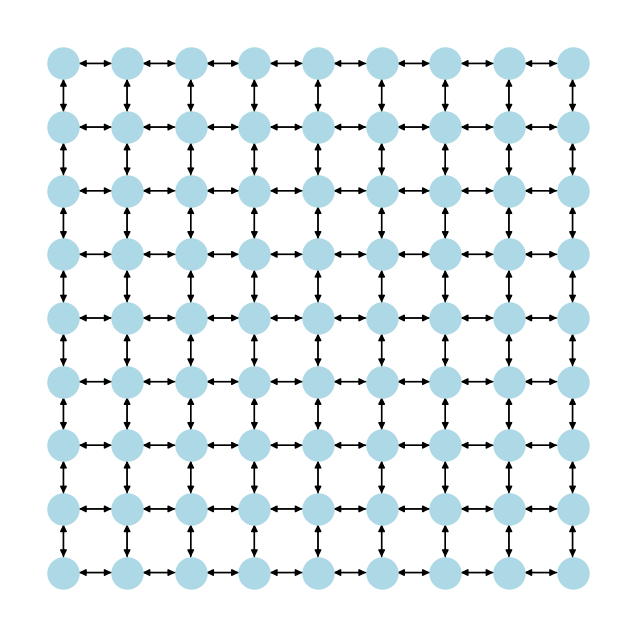

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_graph(grid_graph, ax, pos=grid_graph.pos, with_labels=False)

### Let's have the message-passing network average over neighbors' messages

In [22]:
grid_graph.temp = torch.zeros(grid_graph.num_nodes, 1)

### find coords of center node and set its temp feature to 1
center_node = (grid_graph.num_nodes - 1) // 2
grid_graph.temp[center_node] = 1.0

In [ ]:
### Let's just change the update method from sum to average
class DiffusionNet(MyGraphNet):
    def __init__(self):
        super().__init__(aggr='sum')

    def update(self, aggregate, x):
        ### x represents the node being updated (i.e. destination)
        return (x + aggregate) / 5.0  # 4 neighbors + self (Note: this isn't exactly correct at the edges)
    
diffusion_net = DiffusionNet()

In [24]:
### Run time steps
num_steps = 10
temp_grids = [grid_graph.temp.clone()]
for step in range(num_steps):
    grid_graph.node_feature = grid_graph.temp
    grid_graph.temp = diffusion_net(grid_graph)
    temp_grids.append(grid_graph.temp.clone())

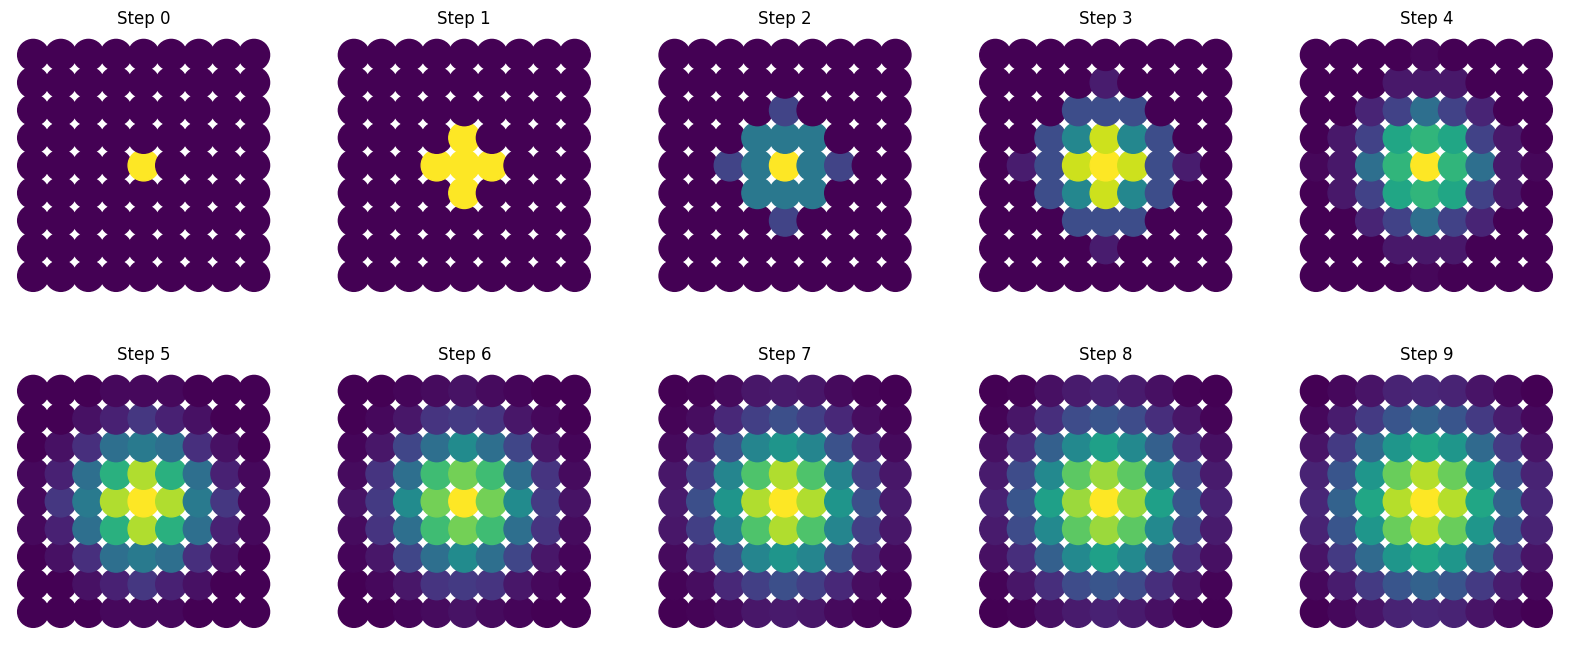

In [25]:
### plot the grid at each timestep
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i in range(num_steps):
    ax = axes[i // 5, i % 5]
    plot_graph(grid_graph, ax, pos=grid_graph.pos, node_feats=temp_grids[i], with_labels=False)
    ax.set_title(f"Step {i}")
plt.show()

## Adjacency matrix

Nodes are rows/columns and we put a 1 at combinations which are connected by an edge

In [26]:
def get_adjacency_matrix(g):

    ### Start with zeros (num_nodes x num_nodes)
    A = torch.zeros((g.num_nodes, g.num_nodes), dtype=torch.float)

    ### Put a 1 for each pair of src and dst nodes that are connected
    edges_src, edges_dst = g.edge_index
    A[edges_src, edges_dst] = 1.0

    return A

def plot_adjacency_matrix(A, ax):
    ax.imshow(A, cmap='binary')
    ax.set_title("Adjacency Matrix")
    ax.set_xlabel("Destination Node Index")
    ax.set_ylabel("Source Node Index")

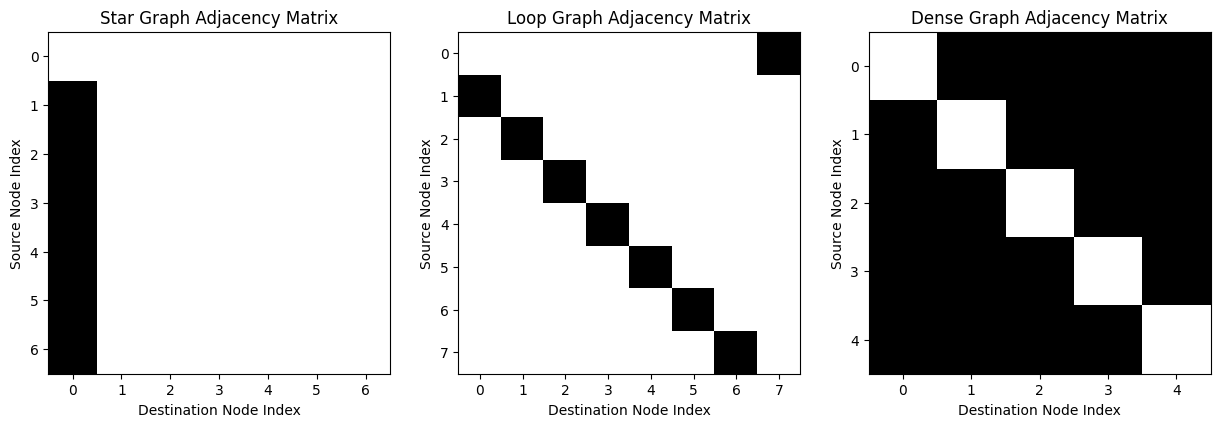

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
graph_collection = {
    "Star Graph": get_star_graph(),
    "Loop Graph": get_loop_graph(),
    "Dense Graph": get_dense_graph()
}
for i, (name, g_) in enumerate(graph_collection.items()):
    A = get_adjacency_matrix(g_)
    plot_adjacency_matrix(A, ax[i])
    ax[i].set_title(f"{name} Adjacency Matrix")
plt.show()

# Batching graphs

Graphs in datasets typically have widely varying numbers of nodes

==> We need to find a way to concatenate them into a batched tensor

In [28]:
for label, g in graph_collection.items():
    print(f"{label}: {g}")

Star Graph: Data(edge_index=[2, 6], num_nodes=7)
Loop Graph: Data(edge_index=[2, 8], num_nodes=8)
Dense Graph: Data(edge_index=[2, 20], num_nodes=5)


### `torch_geometric.loader.DataLoader`

In [29]:
from torch_geometric.loader import DataLoader

class MyLittleGraphDataset(torch.utils.data.Dataset):
    def __init__(self, graphs): self.graphs = graphs
    def __len__(self): return len(self.graphs)
    def __getitem__(self, i): return self.graphs[i]

ds = MyLittleGraphDataset(list(graph_collection.values()))
dl = DataLoader(ds, batch_size=3, shuffle=False)

In [30]:
for batch in dl:
    print(batch)

DataBatch(edge_index=[2, 34], num_nodes=20, batch=[20], ptr=[4])


batch.ptr: [ 0  7 15 20]


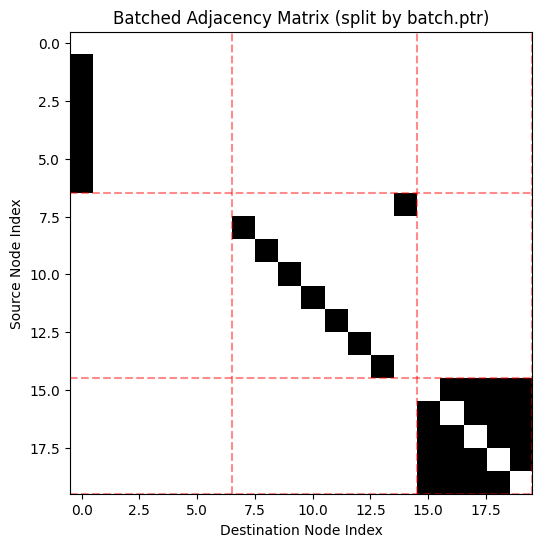

In [31]:
A_batched = get_adjacency_matrix(batch)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plot_adjacency_matrix(A_batched, ax)
ax.set_title("Batched Adjacency Matrix (split by batch.ptr)")

### batch.ptr stores cumulative node offsets for each graph in the batch
ptr = batch.ptr.cpu().numpy()
print("batch.ptr:", ptr)

for p in ptr:
    ax.axhline(p - 0.5, color='red', linestyle='--', alpha=0.45)
    ax.axvline(p - 0.5, color='red', linestyle='--', alpha=0.45)

for i in range(len(ptr) - 1):
    start, end = ptr[i], ptr[i + 1]
    center = (start + end - 1) / 2

plt.show()

### We can also unbatch it

In [32]:
graphs_in_batch = batch.to_data_list()
for i, g in enumerate(graphs_in_batch):
    print(f"Graph {i} in batch: {g}")

Graph 0 in batch: Data(edge_index=[2, 6], num_nodes=7)
Graph 1 in batch: Data(edge_index=[2, 8], num_nodes=8)
Graph 2 in batch: Data(edge_index=[2, 20], num_nodes=5)
